In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("smartcart_customers.csv")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.isnull().sum()  

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing 

## 1.Handling missing data

In [6]:
data["Income"]=data["Income"].fillna(data["Income"].median()) # Replace null values with the mean value 

In [7]:
data.isnull().sum().head()

ID                0
Year_Birth        0
Education         0
Marital_Status    0
Income            0
dtype: int64

## 2.feature enginnering 

In [8]:
# adding new feature of age by replacing year-birth column 

data["Age"]=2026-data["Year_Birth"]

In [9]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age'],
      dtype='object')

In [10]:
# customer joining data

data["Dt_Customer"]=pd.to_datetime(data["Dt_Customer"],dayfirst=True)
referance_date=data["Dt_Customer"].max()
data["customer_tenure_days"]=(referance_date-data["Dt_Customer"]).dt.days

In [11]:
# spendings
data["total_spending"]=data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]

In [12]:
#children
data["total_children"]=data["Kidhome"]+data["Teenhome"]

In [13]:
# education
data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
# replace 1) Graduation with Graduate 2) 2n cycle and basic with Undergraduate and 3) master and phd with postgreduate
data["Education"]=data["Education"].replace({
            "2n Cycle":"Undergraduate","Basic":"Undergraduate",
            "Graduation":"Graduate",
            "Master":"Postgraduate",
            "PhD":"Postgraduate"
})

In [15]:
data["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [16]:
# marital status
data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [17]:
data["Living_With"]=data["Marital_Status"].replace({
            "Married":"Partner","Together":"Partner",
            "Single":"Alone",
            "Divorced":"Alone",
            "Widow":"Alone",
            "Absurd":"Alone","YOLO":"Alone"
})

In [18]:
data["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop columns

In [19]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [20]:
col=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_col=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
total_cols=col+spending_col

In [21]:
data_clean=data.drop(columns=total_cols,axis=1)

In [22]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  Age                   2240 non-null   int64  
 11  customer_tenure_days  2240 non-null   int64  
 12  total_spending        2240 non-null   int64  
 13  total_children        2240 non-null   int64  
 14  Living_With           2240 non-null   object 
dtypes: float64(1), int64(

# Outliers

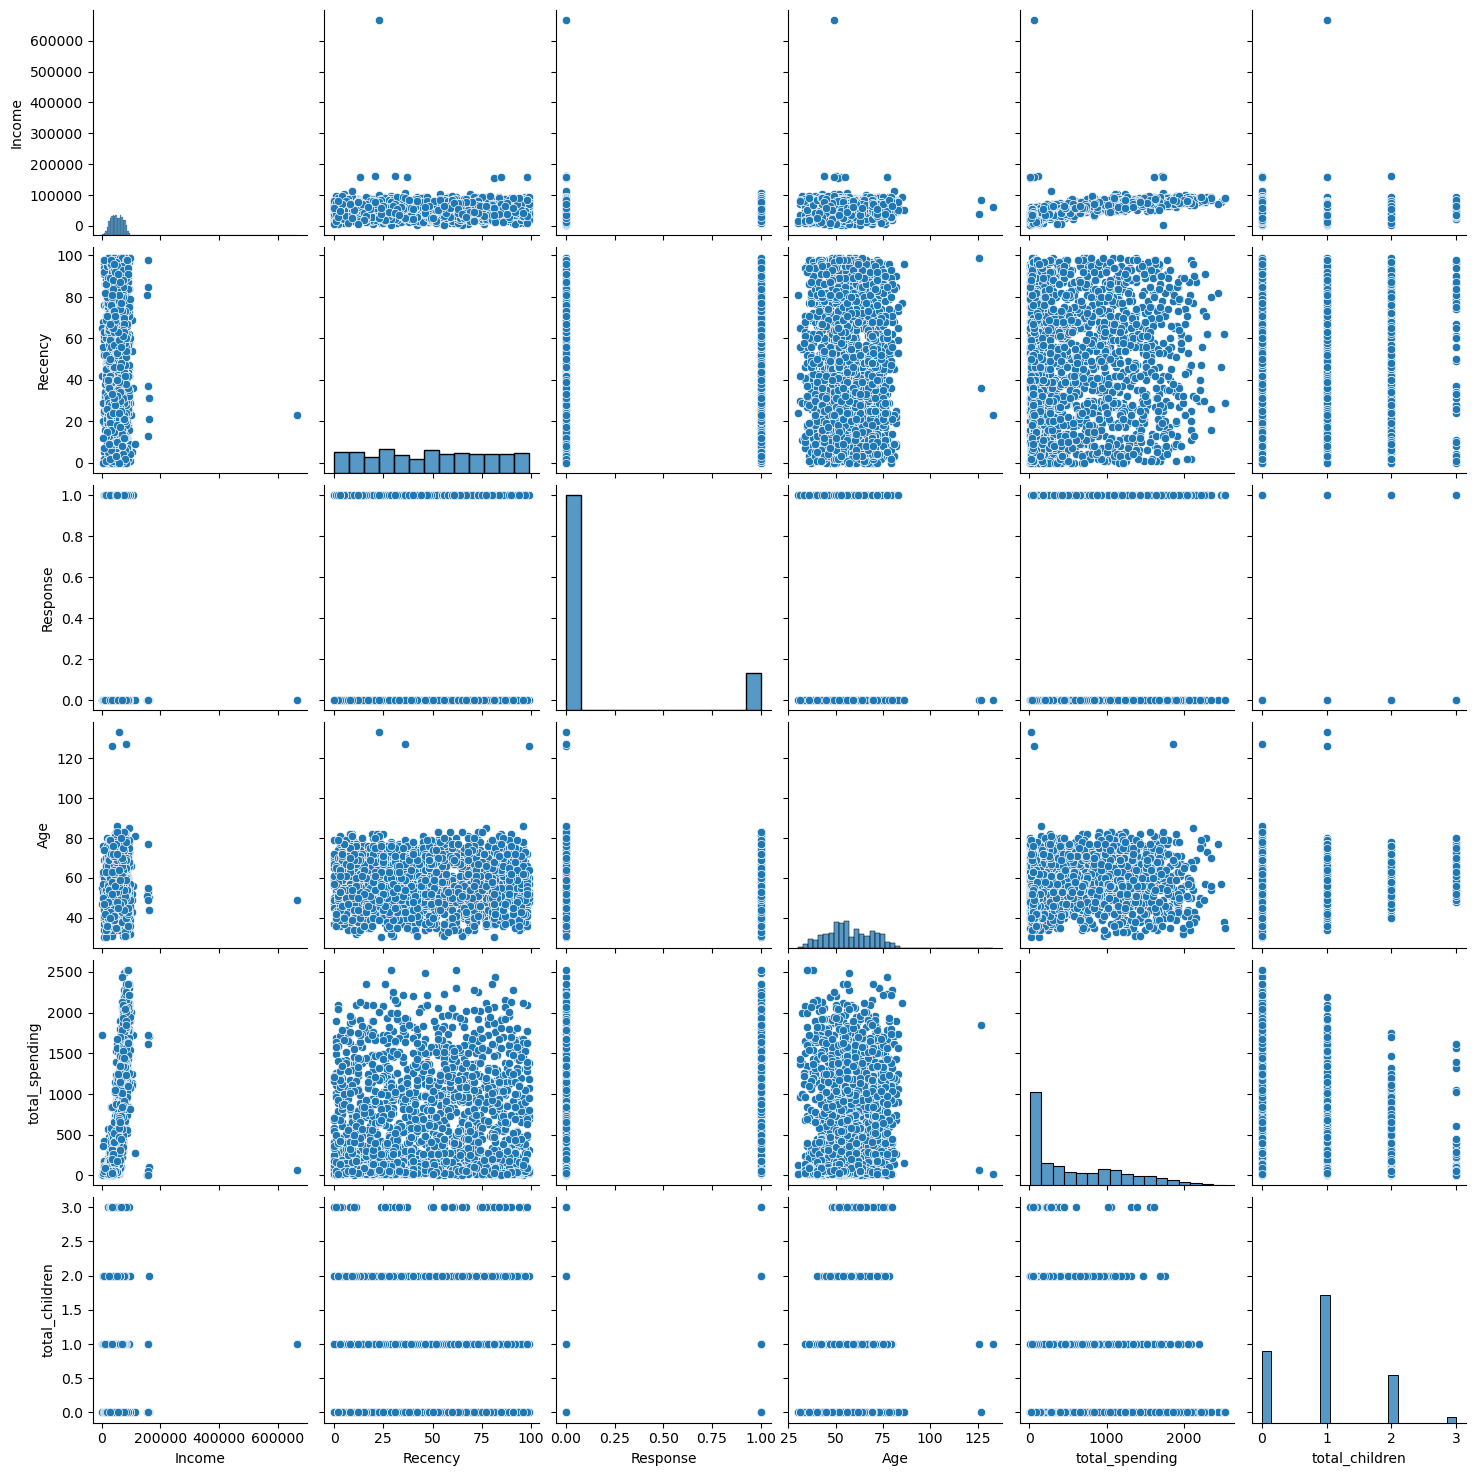

In [23]:
# ploting pair plot to check outlier 
# Relative plot of some features-Pair plot
cols=["Income","Recency","Response","Age","total_spending","total_children"]
sns.pairplot(data_clean[cols])

In [24]:
# Removing outliers 
print("datasize with ouliers",len(data_clean))
data_clean = data_clean[(data_clean["Age"] < 90)]
data_clean = data_clean[(data_clean["Income"] < 600_000)]
print("Data size without outliers:", len(data_clean))

datasize with ouliers 2240
Data size without outliers: 2236


# Heatmap

<Axes: >

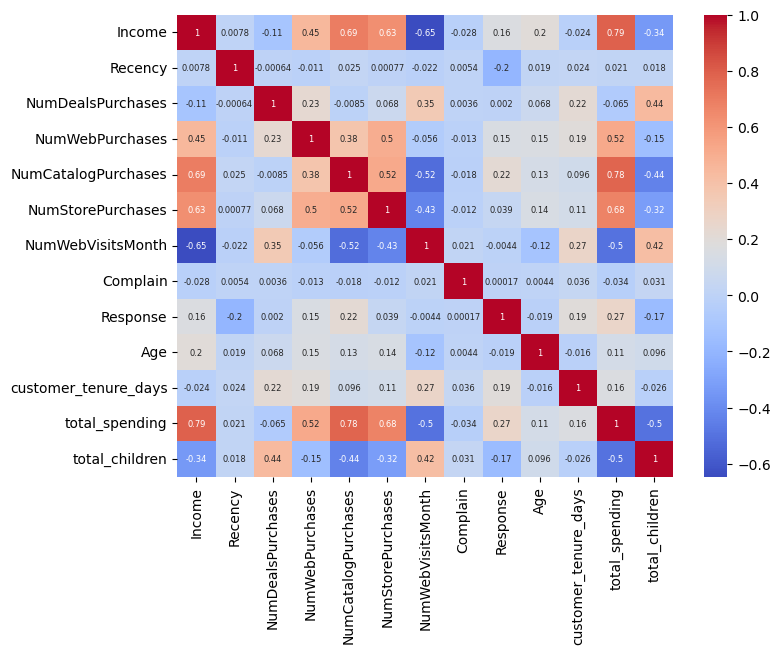

In [25]:
corr=data_clean.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    annot_kws={"size":6}
)

# Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]

In [27]:
encoded_cols=ohe.fit_transform(data_clean[cat_cols])

In [28]:
encoded_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=data_clean.index)

In [29]:
encoded_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [30]:
# concat with main datd
data_encoded=pd.concat([data_clean.drop(columns=cat_cols),encoded_df],axis=1)

In [31]:
data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [32]:
# Scaling
from sklearn.preprocessing import StandardScaler
X=data_encoded

In [33]:
scaler=StandardScaler()
X_scale=scaler.fit_transform(X)

# visualization 

In [34]:
# 2D
from sklearn.decomposition import PCA

In [35]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scale)

In [36]:
X_pca[:,0].shape

(2236,)

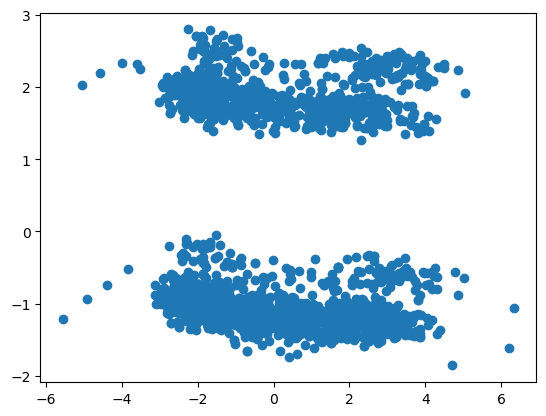

In [37]:
#plot x_pca
plt.scatter(X_pca[:,0],X_pca[:,1])

In [38]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [39]:
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scale)

Text(0.5, 0.92, '3D projection')

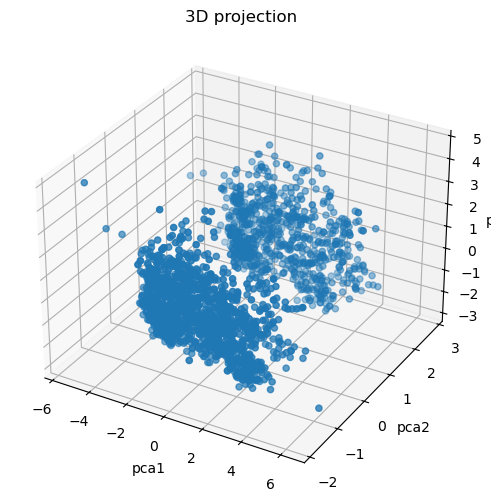

In [40]:
# plot 3D 
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

In [41]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze the K value 

## Elbow method 

In [42]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    model=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

<Axes: >

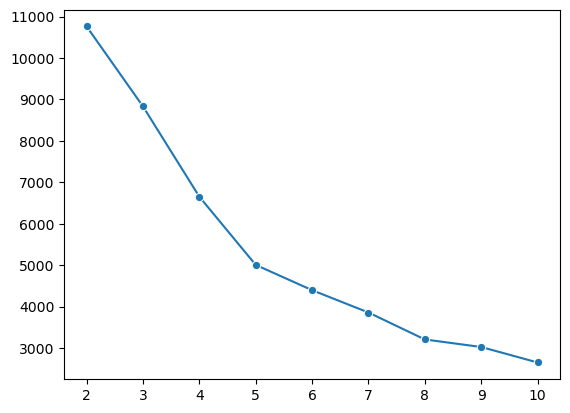

In [43]:
# create plot using wcss and k value
sns.lineplot(x=range(2,11),y=wcss,marker='o')

In [44]:
# cross check using kneed module
from kneed import KneeLocator

kneed=KneeLocator(range(2,11),wcss,curve="convex",direction="decreasing")
optimal_k=kneed.elbow
optimal_k

5

## Silhouette score

In [45]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,label)
    scores.append(score)

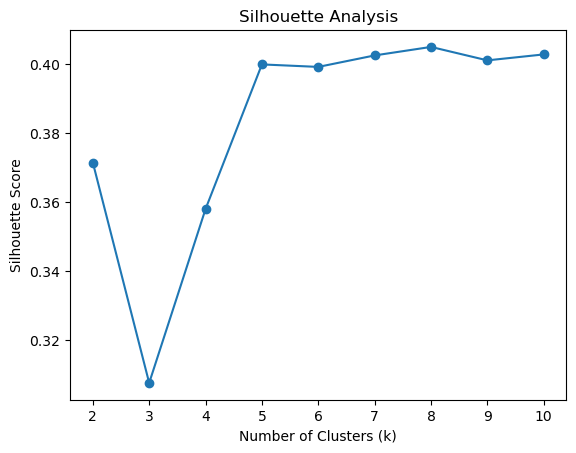

In [46]:
k_values = range(2, 11)

plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

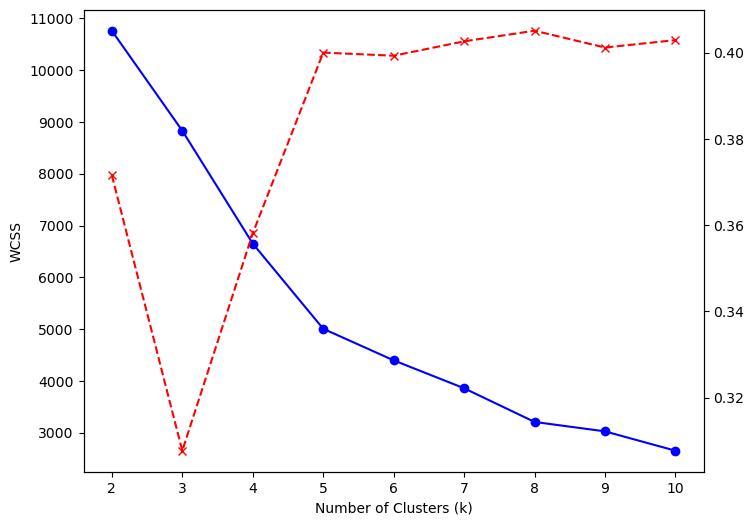

In [47]:
# combine plot of wcss and silhoutte score
k_values = range(2, 11)
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_values, wcss, marker='o',color="blue")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_values,scores[:len(k_values)],marker="x",color="red",linestyle="--")

# Cluster

## KMean

In [48]:
# Kmean 
kmean=KMeans(n_clusters=4,random_state=42)
labels=kmean.fit_predict(X_pca)

Text(0.5, 0.92, '3D projection')

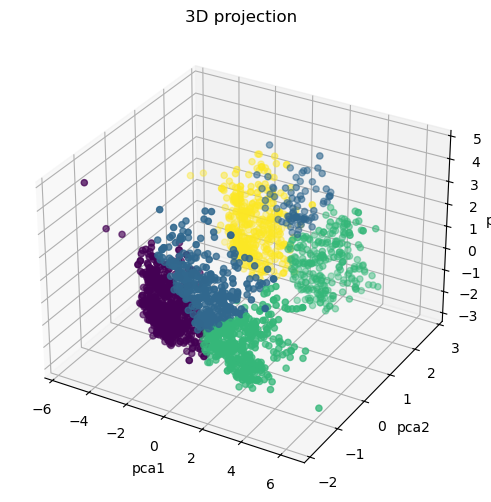

In [49]:
# plot 3D 
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

## Agglomerative clustering 

In [50]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg.fit_predict(X_pca)

Text(0.5, 0.92, '3D projection')

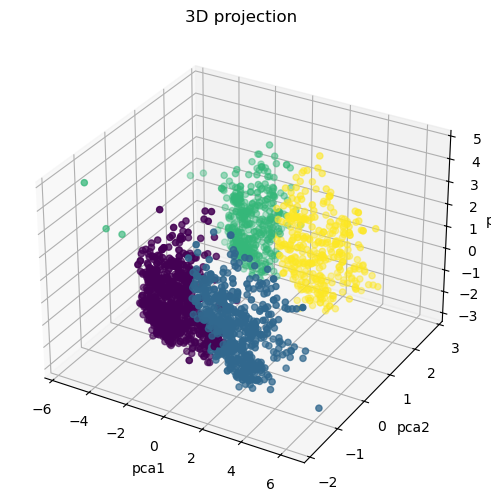

In [51]:
# plot 3D 
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

## characterization of cluster

In [62]:
X["cluster"]=labels_agg

In [63]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

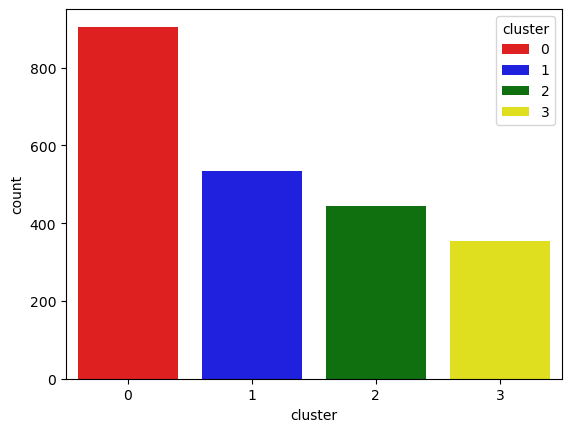

In [64]:
pal=["red","blue","green","yellow"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

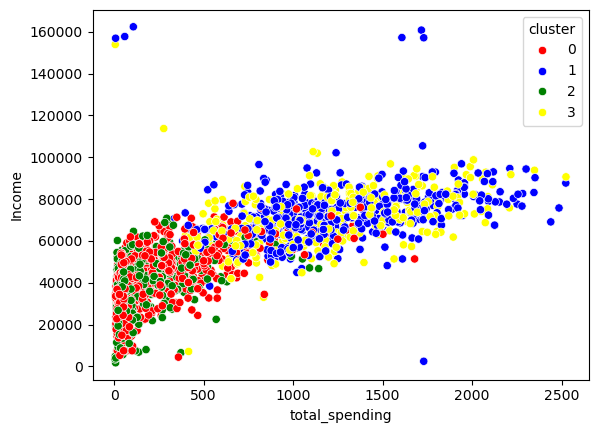

In [65]:
# Income & total spending
sns.scatterplot(x=X["total_spending"],y=X["Income"],hue=X["cluster"],palette=pal)

In [66]:
# cluster summary
cluster_summary=X.groupby("cluster").mean()

In [67]:
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  customer_tenure_days  total_spending  \
cluster         